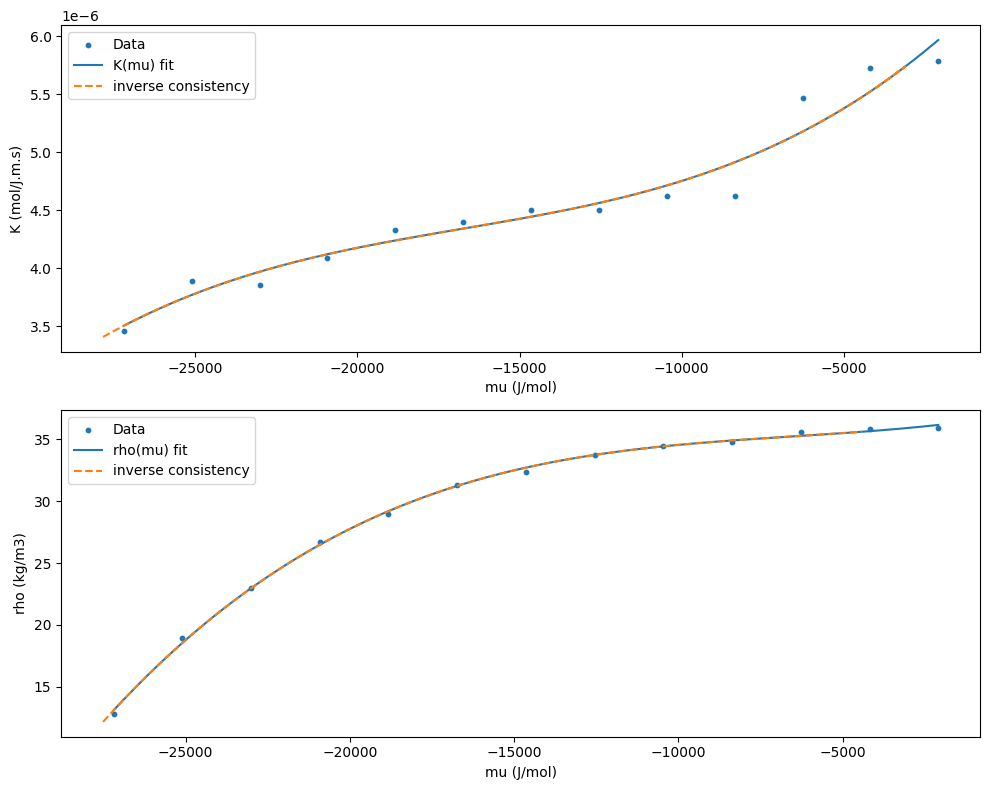

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Constants
# ----------------------------
V = 4e-9 * 4e-9 * 2e-9
m = 1e-3
Na = 6.022e23
kcal_to_j = 4184.0

degree = 3

# ----------------------------
# Load data
# ----------------------------
K_data = np.loadtxt("T300/K_vs_mu.dat")
N_data = np.loadtxt("T300/N_vs_mu.dat")

mu_K, K = K_data[:, 0], K_data[:, 1]
mu_rho = N_data[:, 0]
N = N_data[:, 1]
mu_K *= kcal_to_j # J/mol
mu_rho *= kcal_to_j # J/mol

rho = m * N / V / Na # kg/m3

# ----------------------------
# Fits
# ----------------------------
coeffs_K_vs_mu = np.polyfit(mu_K, K, degree)
coeffs_rho_vs_mu = np.polyfit(mu_rho, rho, degree)
coeffs_mu_vs_K = np.polyfit(K, mu_K, degree)
coeffs_mu_vs_rho = np.polyfit(rho, mu_rho, degree)

with open("T300/K_vs_mu_fit.txt", "w") as f:
    f.write(f"{degree}\n")
    for c in coeffs_K_vs_mu:
        f.write(f"{c}\n")

with open("T300/rho_vs_mu_fit.txt", "w") as f:
    f.write(f"{degree}\n")
    for c in coeffs_rho_vs_mu:
        f.write(f"{c}\n")

with open("T300/mu_vs_K_fit.txt", "w") as f:
    f.write(f"{degree}\n")
    for c in coeffs_mu_vs_K:
        f.write(f"{c}\n")

with open("T300/mu_vs_rho_fit.txt", "w") as f:
    f.write(f"{degree}\n")
    for c in coeffs_mu_vs_rho:
        f.write(f"{c}\n")

poly_K_vs_mu = np.poly1d(coeffs_K_vs_mu)
poly_rho_vs_mu = np.poly1d(coeffs_rho_vs_mu)
poly_mu_vs_K = np.poly1d(coeffs_mu_vs_K)
poly_mu_vs_rho = np.poly1d(coeffs_mu_vs_rho)


# ----------------------------
# Grids
# ----------------------------
mu_grid = np.linspace(min(mu_K), max(mu_K), 300)
K_grid = np.linspace(min(K), max(K), 300)
rho_grid = np.linspace(min(rho), max(rho), 300)

# Forward fits
K_fit = poly_K_vs_mu(mu_grid)
rho_fit = poly_rho_vs_mu(mu_grid)

# CONSISTENCY 

# K consistency
mu_from_K = poly_mu_vs_K(K_grid)
K_back = poly_K_vs_mu(mu_from_K)   # map back

# rho consistency
mu_from_rho = poly_mu_vs_rho(rho_grid)
rho_back = poly_rho_vs_mu(mu_from_rho)

plt.figure(figsize=(10, 8))

# ----------------------------
# 1. K(mu)
# ----------------------------
plt.subplot(2, 1, 1)
plt.scatter(mu_K, K, s=10, label="Data")
plt.plot(mu_grid, K_fit, label="K(mu) fit")

# # inverse consistency (round-trip)
plt.plot(mu_from_K, K_back, "--", label="inverse consistency")

plt.xlabel("mu (J/mol)")
plt.ylabel("K (mol/J.m.s)")
plt.legend()

# ----------------------------
# 2. rho(mu)
# ----------------------------
plt.subplot(2, 1, 2)
plt.scatter(mu_rho, rho, s=10, label="Data")
plt.plot(mu_grid, rho_fit, label="rho(mu) fit")

# # inverse consistency (round-trip)
plt.plot(mu_from_rho, rho_back, "--", label="inverse consistency")

plt.xlabel("mu (J/mol)")
plt.ylabel("rho (kg/m3)")
plt.legend()

plt.tight_layout()
plt.show()
